# DengAI · 5. Results, error analysis and conclusions

1. Validation results
2. What the forecasts look like
3. Error analysis: where the model fails
4. What the network relies on (permutation importance)
5. Final model and submission
6. Hidden-test (leaderboard) results
7. Real-life usefulness and impact
8. Conclusions

Requires the outputs of notebook 04 (`notebooks/outputs/`).

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "dengai").is_dir())
sys.path.insert(0, str(ROOT))
OUTPUT_DIR = ROOT / "notebooks" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dengai import features as F
from dengai.config import (CITIES, CITY_NAMES, DATE_COLUMN, LEADERBOARD_HISTORY, SUMMARY_NAMES, TARGET_COLUMN,
                           WEATHER_FEATURES, MLPConfig)
from dengai.data import city_frame, find_data_dir, interpolate_climate, load_data, make_submission
from dengai.models import SeluMLP, to_cases, tree_model
from dengai.plotting import ACTUAL_COLOR, CITY_COLORS, MUTED, SERIES, set_style
from dengai.validation import interpolated_cities, summarize, temporal_folds

set_style()
train, test, template = load_data(find_data_dir(ROOT))
cities = interpolated_cities(train)
runs = pd.read_csv(OUTPUT_DIR / "cv_predictions.csv", parse_dates=[DATE_COLUMN])
overall = pd.read_csv(OUTPUT_DIR / "cv_summary.csv", index_col="model")
selected = json.loads((OUTPUT_DIR / "selected_models.json").read_text())
MLP_CONFIGS = {c: MLPConfig(**{k: v for k, v in selected["mlp"][c].items() if k != "name"}) for c in CITIES}
FINAL = "MLP · multiscale"
MLP_CONFIGS

{'sj': MLPConfig(hidden_1=100, hidden_2=25, dropout_1=0.3, dropout_2=0.7, learning_rate=0.01),
 'iq': MLPConfig(hidden_1=70, hidden_2=18, dropout_1=0.5, dropout_2=0.5, learning_rate=0.001)}

## 1. Validation results (3 years × 3 seeds, from notebook 04)

In [2]:
overall.round(2)

,iq,sj,weighted,improvement vs seasonal
model,,,,
Median baseline,7.69,21.22,16.15,-0.09
Seasonal median,7.39,19.21,14.78,0.00
Trees (tuned),7.26,12.99,10.84,0.27
MLP · raw lags,8.04,20.63,15.91,-0.08
MLP · raw + multiscale,7.61,20.32,15.56,-0.05
MLP · multiscale,7.71,18.96,14.74,0.00
Blend · ½ trees + ½ MLP,7.33,13.26,11.04,0.25


## 2. What the forecasts look like on the validation years

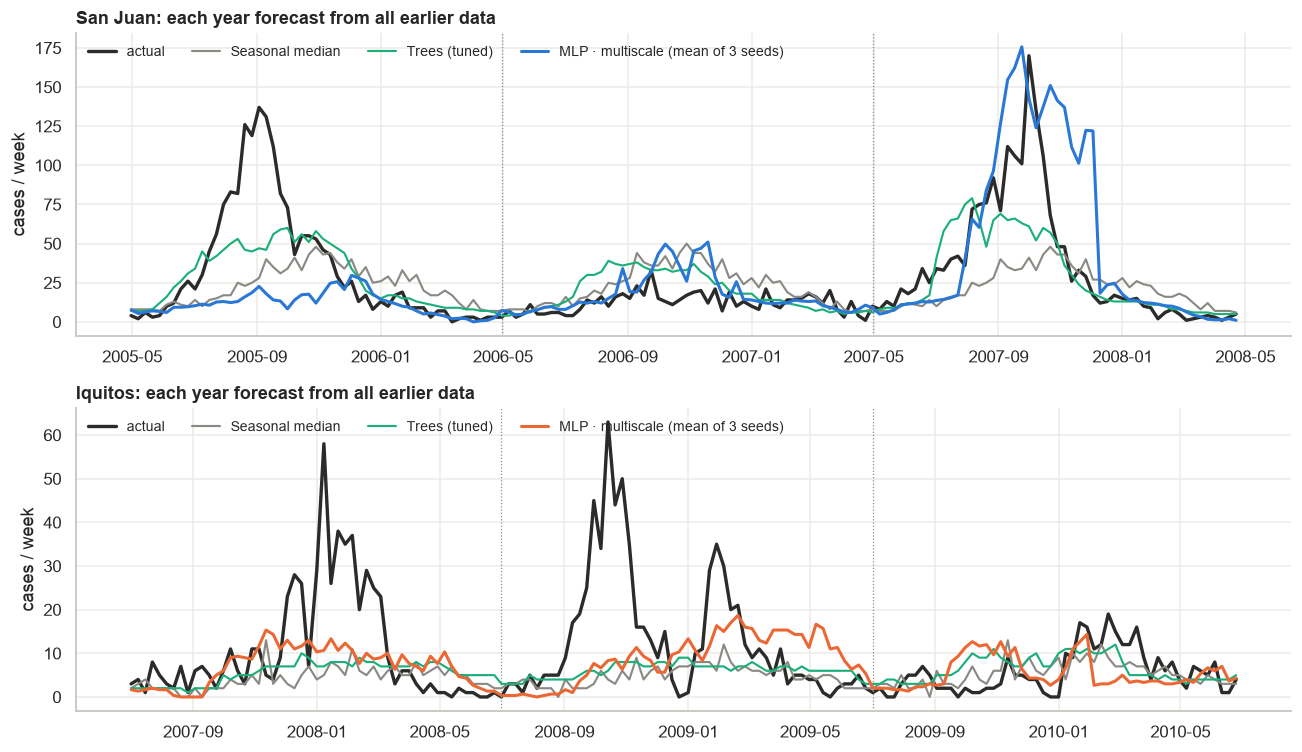

In [3]:
mlp_mean = (runs[runs["model"].eq(FINAL)]
            .groupby(["city", "fold", DATE_COLUMN], as_index=False)
            .agg(actual=("actual", "first"), prediction=("prediction", "mean")))
show = {"Seasonal median": MUTED, "Trees (tuned)": SERIES[2]}
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, city in zip(axes, CITIES):
    actual = mlp_mean[mlp_mean["city"].eq(city)]
    ax.plot(actual[DATE_COLUMN], actual["actual"], color=ACTUAL_COLOR, lw=2.2, label="actual")
    for model, color in show.items():
        r = runs[runs["model"].eq(model) & runs["city"].eq(city)]
        ax.plot(r[DATE_COLUMN], r["prediction"], color=color, lw=1.4, label=model)
    ax.plot(actual[DATE_COLUMN], actual["prediction"], color=CITY_COLORS[city], lw=2, label=f"{FINAL} (mean of 3 seeds)")
    for fold_start in actual.groupby("fold")[DATE_COLUMN].min().iloc[1:]:
        ax.axvline(fold_start, color=MUTED, lw=0.8, ls=":")
    ax.set(title=f"{CITY_NAMES[city]}: each year forecast from all earlier data", ylabel="cases / week", xlabel="")
    ax.legend(ncols=4, loc="upper left", fontsize=9)
plt.tight_layout()

## 3. Error analysis

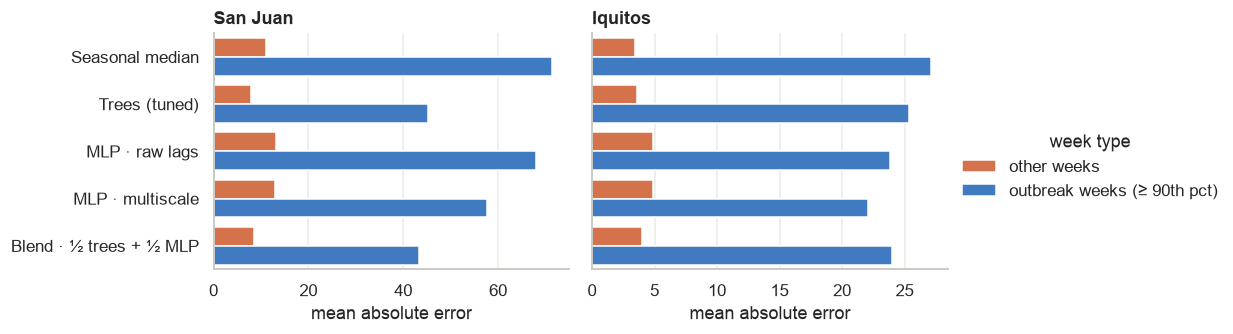

In [4]:
MODELS = ["Seasonal median", "Trees (tuned)", "MLP · raw lags", FINAL, "Blend · ½ trees + ½ MLP"]
compare = runs[runs["model"].isin(MODELS)].copy()
compare["week type"] = np.where(compare["outbreak"], "outbreak weeks (≥ 90th pct)", "other weeks")
compare["City"] = compare["city"].map(CITY_NAMES)
g = sns.catplot(data=compare, x="abs_error", y="model", hue="week type", col="City", kind="bar",
                errorbar=None, palette=[SERIES[1], SERIES[0]], height=3.2, aspect=1.5, sharex=False,
                order=MODELS)
g.set_titles("{col_name}")
g.set_axis_labels("mean absolute error", "");

In [5]:
final = runs[runs["model"].eq(FINAL)].copy()
final["error"] = final["prediction"] - final["actual"]
bias = (final.groupby(["city", "fold"])
        .agg(actual_mean=("actual", "mean"), prediction_mean=("prediction", "mean"),
             mean_error=("error", "mean"), mae=("abs_error", "mean"),
             outbreak_weeks=("outbreak", lambda s: int(s.sum() / 3)),
             actual_peak=("actual", "max"), predicted_peak=("prediction", "max")))
bias.round(1)

actual_mean  prediction_mean  mean_error   mae  outbreak_weeks  \
city fold                                                                   
iq   1            10.8              7.0        -3.8   7.8              13   
     2            13.3              8.8        -4.5  10.7              13   
     3             5.7              5.5        -0.2   4.6               0   
sj   1            34.4             11.7       -22.7  25.4              10   
     2            12.1             17.8         5.7   8.3               0   
     3            36.1             50.1        13.9  23.1              11   

           actual_peak  predicted_peak  
city fold                               
iq   1              58              18  
     2              63              19  
     3              19              16  
sj   1             137              41  
     2              33              64  
     3             170             194

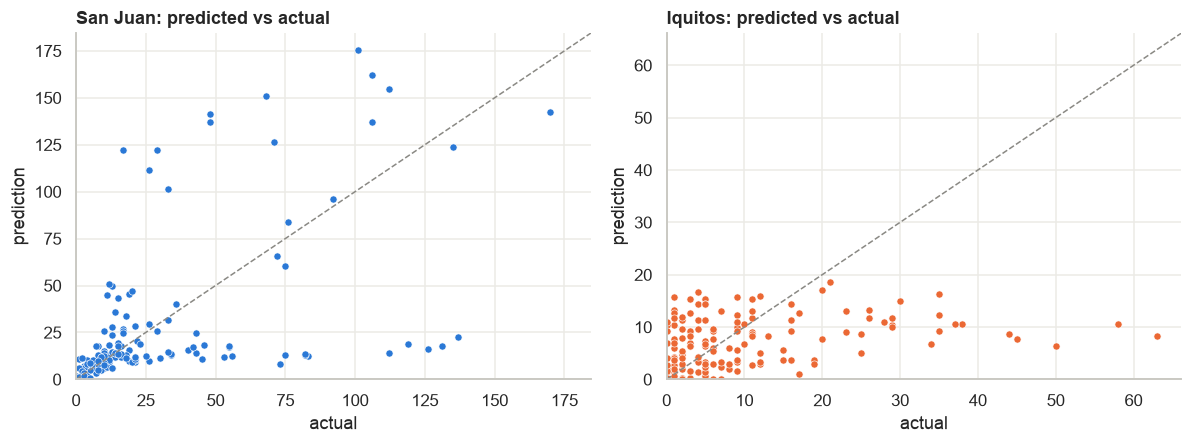

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, city in zip(axes, CITIES):
    d = mlp_mean[mlp_mean["city"].eq(city)]
    top = max(d["actual"].max(), d["prediction"].max()) * 1.05
    ax.plot([0, top], [0, top], color=MUTED, lw=1, ls="--")
    sns.scatterplot(data=d, x="actual", y="prediction", ax=ax, color=CITY_COLORS[city], s=22, edgecolor="white", linewidth=0.4)
    ax.set(title=f"{CITY_NAMES[city]}: predicted vs actual", xlim=(0, top), ylim=(0, top))
plt.tight_layout()

**What the error analysis shows** (numbers above):

* Most of the absolute error comes from **outbreak weeks**. Peaks are
  usually under-predicted: San Juan 2005 peaked at 137 and the MLP
  predicted at most 41; Iquitos peaks near 60 were predicted below 20.
* The MLP's errors are **all-or-nothing on amplitude**. It missed San
  Juan's 2005 outbreak, then over-predicted 2007 (peak 194 vs 170) and
  stayed high for too long. The trees predict moderate seasonal bumps
  every year, which costs less MAE when the timing is uncertain.
* The **sign of the yearly error changes between years** (mean error per
  fold). A climate-only model gets the rough level of a season, but cannot
  know population immunity or which serotype circulates. Those factors
  decide whether a season becomes an epidemic.
* By city: in San Juan the trees and the blend have the lowest error on
  both kinds of week. In Iquitos the trees win on ordinary weeks, but the
  MLP has the lowest outbreak error.

## 4. What does the network rely on?

Permutation importance: on each validation year, shuffle a group of input
columns (all 11 summaries of one variable, or one summary type across all
variables) and measure how much the MAE increases. The model is fitted
once per fold (seed 42); importances are averaged over 3 folds × 5
shuffles.

In [7]:
names = np.array(F.multiscale_names())
variable_groups = {v: np.flatnonzero(np.char.startswith(names, v + "__")) for v in WEATHER_FEATURES}
variable_groups["season (harmonics)"] = np.flatnonzero(np.char.startswith(names, "season_"))
summary_groups = {s: np.flatnonzero(np.char.endswith(names, "__" + s)) for s in SUMMARY_NAMES}

rng = np.random.default_rng(0)
rows = []
for city in CITIES:
    for fold in temporal_folds(cities, city, n_folds=3):
        stats = F.normalization_stats(fold.sj_reference)
        x, y = F.training_matrix(fold.train, city, stats, F.MULTISCALE)
        vx = F.prediction_matrix(fold.train, fold.valid, city, stats, F.MULTISCALE)
        vy = fold.valid[TARGET_COLUMN].to_numpy()
        model = SeluMLP(city, MLP_CONFIGS[city], seed=42).fit(x, y)
        base = np.abs(to_cases(model.predict(vx)) - vy).mean()
        for kind, groups in (("variable", variable_groups), ("summary", summary_groups)):
            for group, cols in groups.items():
                for _ in range(5):
                    shuffled = vx.copy()
                    shuffled[:, cols] = shuffled[rng.permutation(len(vx))][:, cols]
                    rows.append({"City": CITY_NAMES[city], "kind": kind, "group": group,
                                 "MAE increase": np.abs(to_cases(model.predict(shuffled)) - vy).mean() - base})
importance = pd.DataFrame(rows)

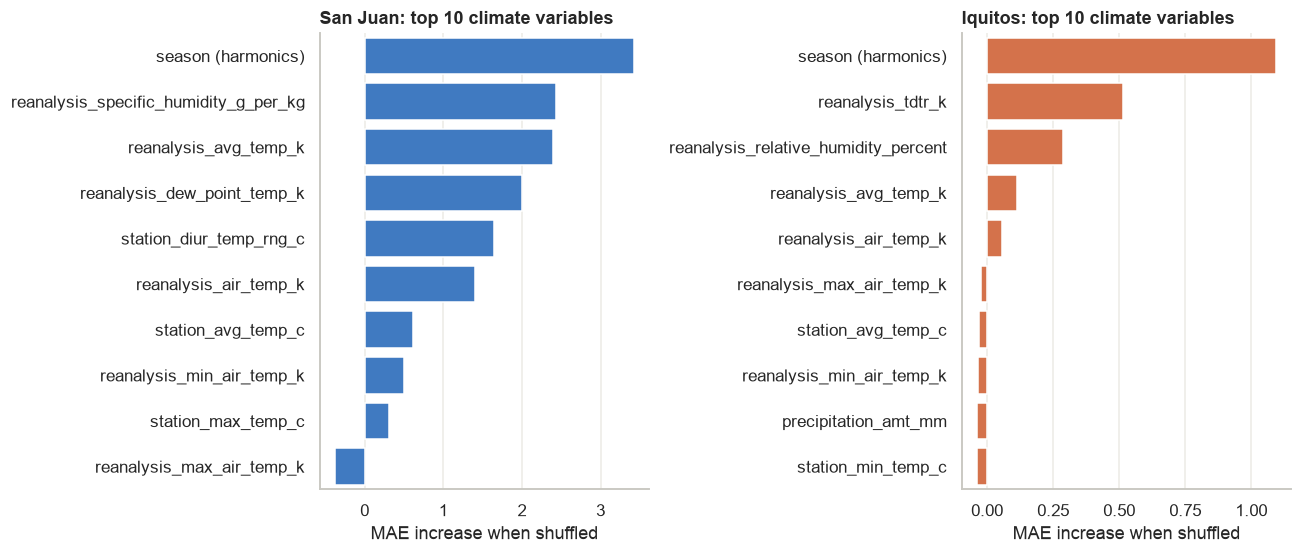

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, (city, name) in zip(axes, CITY_NAMES.items()):
    d = importance[importance["kind"].eq("variable") & importance["City"].eq(name)]
    order = d.groupby("group")["MAE increase"].mean().sort_values(ascending=False).index[:10]
    sns.barplot(data=d, y="group", x="MAE increase", order=order, color=CITY_COLORS[city], errorbar=None, ax=ax)
    ax.set(title=f"{name}: top 10 climate variables", ylabel="", xlabel="MAE increase when shuffled")
plt.tight_layout()

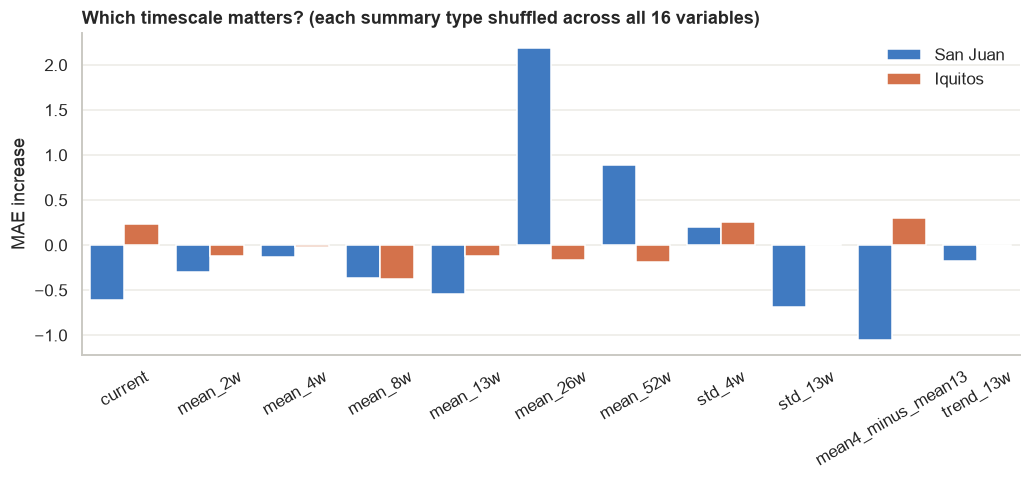

In [9]:
d = importance[importance["kind"].eq("summary")]
fig, ax = plt.subplots(figsize=(11, 3.8))
sns.barplot(data=d, x="group", y="MAE increase", hue="City", palette=CITY_COLORS, errorbar=None,
            order=SUMMARY_NAMES, ax=ax)
ax.set(title="Which timescale matters? (each summary type shuffled across all 16 variables)", xlabel="", ylabel="MAE increase")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="");

**Reading the importances.** The seasonal harmonics matter most in both
cities. In San Juan the network relies on humidity, dew point and
temperature, mostly through their **26- and 52-week means**: the
accumulated climate of the past half-year to year. In Iquitos it uses
the diurnal temperature range and relative humidity, and the current
and short-term values. Negative bars (shuffling *improves* the error)
are summaries the model fits to noise. This is a sign of overfitting
with so few labels, and a candidate list for pruning the representation.

## 5. Final model and submission

The final model is refit on **all** training weeks of each city with the
configuration selected in notebook 04, seed 42 (the seed of the
leaderboard-confirmed submission). Seeds 17 and 73 are fitted too, to
show how much a single run varies.

In [10]:
stats = F.normalization_stats(cities["sj"])
test_cities = {c: interpolate_climate(city_frame(test, c)) for c in CITIES}
test_predictions, seed_spread = {}, []
for city in CITIES:
    x, y = F.training_matrix(cities[city], city, stats, F.MULTISCALE)
    x_test = F.prediction_matrix(cities[city], test_cities[city], city, stats, F.MULTISCALE)
    for seed in (42, 17, 73):
        model = SeluMLP(city, MLP_CONFIGS[city], seed=seed).fit(x, y)
        cases = to_cases(model.predict(x_test))
        if seed == 42:
            test_predictions[city] = cases
            print(f"{CITY_NAMES[city]}: {model.n_parameters:,} parameters, final training MAE {model.history_[-1]:.2f}")
        seed_spread.append({"City": CITY_NAMES[city], "seed": seed, "mean": cases.mean(), "max": cases.max()})

submission = make_submission(template, test_predictions)
assert submission[["city", "year", "weekofyear"]].equals(template[["city", "year", "weekofyear"]])
assert len(submission) == 416 and submission[TARGET_COLUMN].ge(0).all()
submission_path = OUTPUT_DIR / "submission_multiscale_mlp.csv"
submission.to_csv(submission_path, index=False)
print("wrote", submission_path.relative_to(ROOT))
pd.DataFrame(seed_spread).pivot(index="seed", columns="City").round(1)

San Juan: 20,651 parameters, final training MAE 11.31


Iquitos: 13,967 parameters, final training MAE 4.51


wrote notebooks/outputs/submission_multiscale_mlp.csv


mean              max         
City Iquitos San Juan Iquitos San Juan
seed                                  
17       3.5     47.5      18      237
42       2.5     47.9      13      232
73       3.5     49.2      15      255

wrote notebooks/outputs/submission_blend_trees_mlp.csv (hedge, not yet scored)


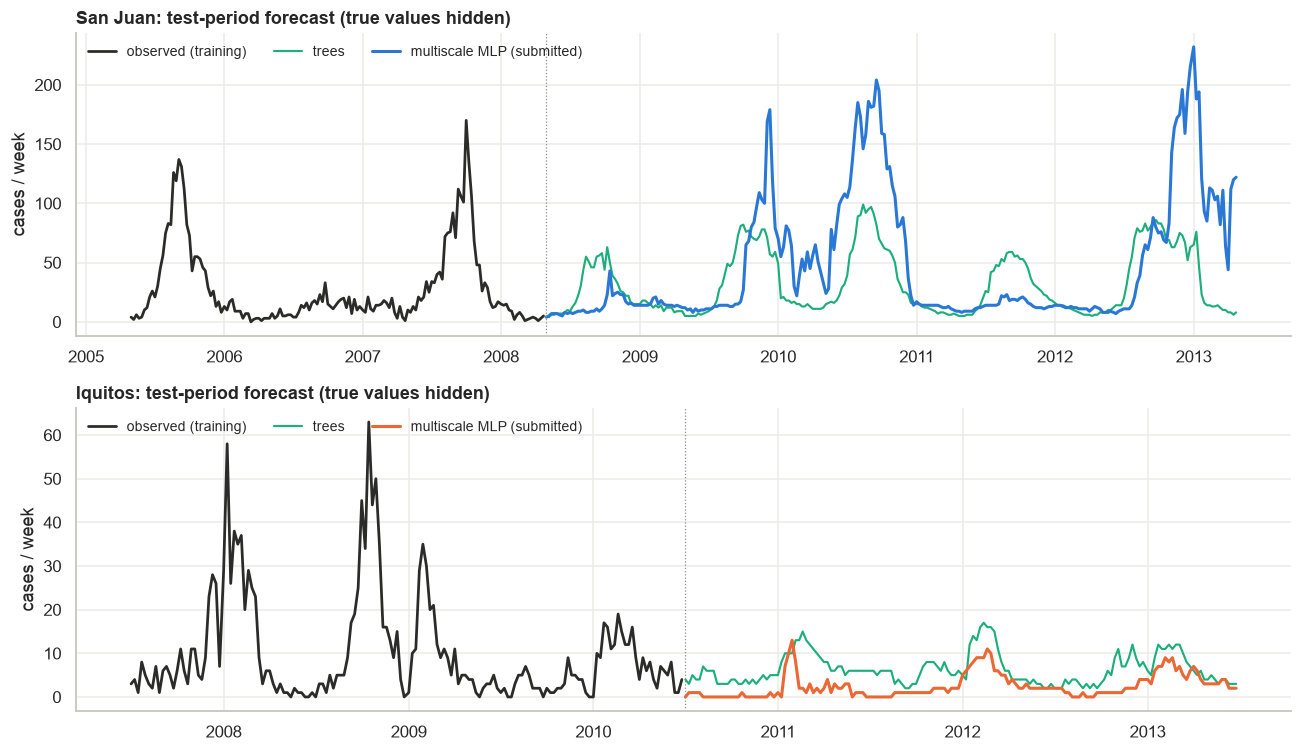

In [11]:
tree_params = selected["trees"]
tree_test = {}
for city in CITIES:
    combined = pd.concat([city_frame(train, city), city_frame(test, city)], ignore_index=True)
    feats, n = F.tree_features(combined), int(train["city"].eq(city).sum())
    model = tree_model(city, 500, **tree_params[city]).fit(feats.iloc[:n], combined[TARGET_COLUMN].iloc[:n])
    tree_test[city] = to_cases(model.predict(feats.iloc[n:]), "round")

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, city in zip(axes, CITIES):
    history = cities[city].iloc[-156:]
    dates = test_cities[city][DATE_COLUMN]
    ax.plot(history[DATE_COLUMN], history[TARGET_COLUMN], color=ACTUAL_COLOR, lw=1.8, label="observed (training)")
    ax.plot(dates, tree_test[city], color=SERIES[2], lw=1.4, label="trees")
    ax.plot(dates, test_predictions[city], color=CITY_COLORS[city], lw=2, label="multiscale MLP (submitted)")
    ax.axvline(dates.iloc[0], color=MUTED, lw=0.8, ls=":")
    ax.set(title=f"{CITY_NAMES[city]}: test-period forecast (true values hidden)", ylabel="cases / week", xlabel="")
    ax.legend(ncols=3, loc="upper left", fontsize=9)
plt.tight_layout()

blend_submission = make_submission(template, {c: to_cases(0.5 * tree_test[c] + 0.5 * test_predictions[c]) for c in CITIES})
blend_submission.to_csv(OUTPUT_DIR / "submission_blend_trees_mlp.csv", index=False)
print("wrote", (OUTPUT_DIR / "submission_blend_trees_mlp.csv").relative_to(ROOT), "(hedge, not yet scored)")

In [12]:
reference = ROOT / "artifacts" / "submission_feature_lag_mlp_multiscale_summaries_seed42.csv"
if reference.exists():
    ref = pd.read_csv(reference)
    diff = (ref[TARGET_COLUMN] - submission[TARGET_COLUMN]).abs()
    print(f"vs {reference.name}: identical rows {np.mean(diff == 0):.1%}, mean |difference| {diff.mean():.2f} cases")

vs submission_feature_lag_mlp_multiscale_summaries_seed42.csv: identical rows 100.0%, mean |difference| 0.00 cases


The refactored pipeline reproduces the repository's earlier NumPy
reproduction of the seed-42 multiscale submission exactly. The file
originally scored at 16.6 was produced with TensorFlow, so small
differences from that file are expected.

The forest forecast is a smooth, repeating seasonal curve, while the MLP
lets each season's height follow the climate. It forecasts large San Juan
seasons in 2009–2010 and 2012–13, a period that includes Puerto Rico's
major 2010 dengue epidemic. If those large seasons occurred, the
amplitude the MLP is penalised for on the calmer validation years pays off
here. That would fit its much better hidden-test score. The test truth is hidden,
so this plot shows behaviour, not accuracy. Two files are written:
`submission_multiscale_mlp.csv` (the final model) and
`submission_blend_trees_mlp.csv` (the ½ + ½ hedge from notebook 04 §10).

## 6. Hidden-test results (DrivenData leaderboard)

Each stage of the project was submitted to DrivenData, which scores
predictions against the hidden test labels. These submissions used the
original TensorFlow/Keras implementation of the same network (the NumPy
version here follows the same architecture and schedule, but is not
bit-identical).

,stage,hidden-test MAE
0,Earlier baseline,26.7
1,City-specific trees,22.5
2,Raw-lag MLP,19.3
3,"Raw-lag MLP, dropout 0.3/0.7",19.1
4,"Raw-lag MLP, tuned widths",18.8
5,Multiscale MLP (final),16.6
6,"Multiscale MLP, 48→12 (rejected)",18.1


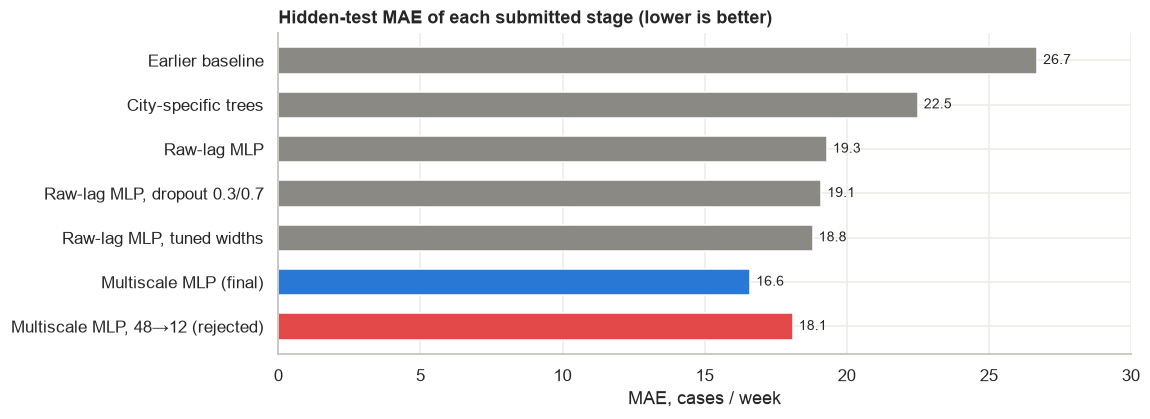

In [13]:
board = pd.DataFrame(LEADERBOARD_HISTORY, columns=["stage", "hidden-test MAE"])
fig, ax = plt.subplots(figsize=(10, 3.8))
colors = [MUTED] * len(board)
colors[board["stage"].tolist().index("Multiscale MLP (final)")] = SERIES[0]
colors[-1] = SERIES[7]
bars = ax.barh(board["stage"], board["hidden-test MAE"], color=colors, height=0.6)
ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=9)
ax.invert_yaxis()
ax.set(title="Hidden-test MAE of each submitted stage (lower is better)", xlabel="MAE, cases / week", xlim=(0, 30))
board

* From the first baseline (26.7) to the final model (16.6) the error
  dropped by **38%**.
* The largest single gain (18.8 → 16.6) came from **changing the
  representation** while keeping the network, training schedule and
  seed fixed.
* The narrower `48 → 12` network that looked slightly better locally
  scored 18.1. Local improvements smaller than the noise do not survive.
* Caveat: after many submissions the leaderboard itself becomes a
  selection set, so 16.6 is somewhat optimistic for truly new data.
* The ranking of trees vs MLP **is the reverse of local validation**
  (notebook 04 §8–10). It is the main open uncertainty of the project.

## 7. Real-life usefulness and impact

A health department does not consume MAE directly. It needs two things:
an **early warning** that a high-incidence period is coming, and the
expected **burden of the season** for budgeting. Both are measured on the
validation years with the model trained only on earlier data.

In [14]:
warning = []
for model in ["Seasonal median", "Trees (tuned)", FINAL, "Blend · ½ trees + ½ MLP"]:
    r = runs[runs["model"].eq(model)].copy()
    for city in CITIES:
        c = r[r["city"].eq(city)]
        threshold = {f.number: np.quantile(f.train[TARGET_COLUMN], 0.75) for f in temporal_folds(cities, city)}
        alarm = c["prediction"] >= c["fold"].map(threshold)
        high = c["outbreak"]
        warning.append({"model": model, "City": CITY_NAMES[city],
                        "high weeks caught (recall)": (alarm & high).sum() / max(high.sum(), 1),
                        "alarms that were real (precision)": (alarm & high).sum() / max(alarm.sum(), 1)})
pd.DataFrame(warning).pivot(index="model", columns="City").round(2)

high weeks caught (recall)           \
City                                       Iquitos San Juan   
model                                                         
Blend · ½ trees + ½ MLP                       0.74     0.57   
MLP · multiscale                              0.79     0.52   
Seasonal median                               0.19     0.19   
Trees (tuned)                                 0.38     1.00   

                        alarms that were real (precision)           
City                                              Iquitos San Juan  
model                                                               
Blend · ½ trees + ½ MLP                              0.32     0.42  
MLP · multiscale                                     0.30     0.43  
Seasonal median                                      0.28     0.17  
Trees (tuned)                                        0.28     0.51

*Alarm rule:* raise an alert when the forecast exceeds the 75th percentile
of past weekly cases; a *high week* is one at or above the 90th
percentile. The forecast for week *t* uses climate up to *t − 2*, so each
alert comes with at least two weeks of lead time for vector control.

In [15]:
burden = (runs[runs["model"].isin(["Seasonal median", "Trees (tuned)", FINAL, "Blend · ½ trees + ½ MLP"])]
          .groupby(["model", "city", "fold", "seed"])[["actual", "prediction"]].sum()
          .groupby(["model", "city", "fold"]).mean().reset_index())
burden["relative error of annual total"] = (burden["prediction"] - burden["actual"]) / burden["actual"]
burden["City"] = burden["city"].map(CITY_NAMES)
burden.pivot(index=["City", "fold"], columns="model", values="relative error of annual total").round(2)

model          Blend · ½ trees + ½ MLP  MLP · multiscale  Seasonal median  \
City     fold                                                               
Iquitos  1                       -0.44             -0.36            -0.60   
         2                       -0.46             -0.34            -0.64   
         3                        0.01             -0.03            -0.05   
San Juan 1                       -0.42             -0.66            -0.34   
         2                        0.51              0.47             0.85   
         3                        0.09              0.39            -0.40   

model          Trees (tuned)  
City     fold                 
Iquitos  1             -0.49  
         2             -0.55  
         3              0.13  
San Juan 1             -0.16  
         2              0.59  
         3             -0.19

In [16]:
board_mae = dict(LEADERBOARD_HISTORY)
first, trees_lb, final_lb = board_mae["Earlier baseline"], board_mae["City-specific trees"], board_mae["Multiscale MLP (final)"]
test_weeks = len(template)
for name, ref in [("first baseline", first), ("tree ensemble", trees_lb)]:
    print(f"vs {name}: {ref} → {final_lb} MAE  ({(ref - final_lb) / ref:.0%} lower), "
          f"≈ {(ref - final_lb) * test_weeks:,.0f} fewer absolute case errors over the {test_weeks} test weeks")

vs first baseline: 26.7 → 16.6 MAE  (38% lower), ≈ 4,202 fewer absolute case errors over the 416 test weeks
vs tree ensemble: 22.5 → 16.6 MAE  (26% lower), ≈ 2,454 fewer absolute case errors over the 416 test weeks


**Impact estimate.** On the hidden test period the final model cuts the
average weekly error by 38% against the first baseline and by 26%
against the tree ensemble. That is a few thousand fewer cases of planning
error (beds, staff, supplies over- or under-allocated) across the test
weeks. On the calmer validation years, however, the trees and the blend
are more accurate overall. For early warning the picture is split: in San
Juan the trees caught every high week (recall 1.00, precision 0.51), while
in Iquitos the MLP caught 79% of high weeks against 38% for the trees.
The size of the benefit therefore depends on the kind of years ahead,
and a cautious deployment would run the blend, or both models side by side.

The model is most useful as a **seasonal risk planner with a short lead
time**: it indicates *when* a season will rise and roughly *how large*
it will be. It is **not** a reliable predictor of the exact height of
rare epidemic peaks. Those depend on immunity and serotype dynamics that
climate data does not contain.

## 8. Conclusions

**Does the model solve the stated problem?** Partly, and usefully:

* ✔ It forecasts weekly cases 3–5 years ahead **from climate alone**
  and scored **16.6 MAE** on the hidden test, against 22.5 for the tree
  ensemble and 26.7 for the first baseline.
* ✔ It gives a two-week lead, enough to schedule vector control and
  hospital capacity for the coming weeks.
* ✘ On the years we can validate locally, the tree ensemble is more
  accurate. Which model is better depends on the period, and only one
  hidden-test score exists for each model.
* ✘ Outbreak peaks are still under-predicted. Decisions near epidemic
  thresholds should combine the forecast with current surveillance data.

**Interesting findings.**

1. **Representation beat raw inputs.** For the same small MLP, 180
   multiscale summaries beat 461 raw weekly values both locally and on
   the hidden test (18.8 → 16.6). In San Juan, raw + summaries was worse
   than the summaries alone, so the benefit comes from filtering weekly
   noise (notebook 03 §6), not from extra information.
2. **Climate memory is long and city-specific.** San Juan responds to
   conditions accumulated over roughly 2–6 months (its network leans on
   26- and 52-week means), Iquitos to the last 1–3 months.
3. **Validation choices decide model selection.** Shuffled K-fold was
   far too optimistic for Iquitos. A local gain of 0.2 MAE after an
   architecture search became a 1.5 MAE loss on the hidden test. Local
   folds and the leaderboard even disagree on trees vs MLP.
4. **Amplitude is a double-edged sword.** The MLP predicts season heights
   that the trees smooth away. That loses on calm years and missed
   outbreaks, but appears to win when large epidemics occur, as in the
   test period.

**Limitations.** Only 3 validation years per city; seed sensitivity of
a small network; the leaderboard was consulted several times; the NumPy
re-implementation is not bit-identical to the submitted Keras model;
reporting practices and immunity change over time.

**Next steps.** Add recent surveillance counts when they are available
(nowcasting); produce prediction intervals (quantile loss) so that
planners see the risk of a peak; average several seeds or models to
reduce variance; add data on serotypes and population immunity.